In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df1=pd.read_csv('/content/True.csv')


In [ ]:
df1.head()


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
df2 = pd.read_csv('/content/Fake.csv')


In [ ]:
df2.head()


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df.to_csv('merged_news.csv', index=False)

In [ ]:
df=pd.read_csv('/content/merged_news.csv')


In [ ]:
df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,title,text,subject,date
count,44898,44898,44898,44898
unique,38729,38646,8,2397
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017"
freq,14,627,11272,182


In [ ]:
df['text_cleaned'] = df['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)
df['title_cleaned'] = df['title'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

In [ ]:
df.head()

,title,text,subject,date,text_cleaned,title_cleaned
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...


In [ ]:
df['tokenized_text'] = df['text_cleaned'].apply(lambda x: x.split())

In [ ]:
df.head()

,title,text,subject,date,text_cleaned,title_cleaned,tokenized_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...,"[washington, reuters, the, head, of, a, conser..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...,"[washington, reuters, transgender, people, wil..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...,"[washington, reuters, the, special, counsel, i..."
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...,"[washington, reuters, trump, campaign, adviser..."
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...,"[seattlewashington, reuters, president, donald..."


In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['text_without_stopwords'] = df['tokenized_text'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df[['tokenized_text', 'text_without_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,tokenized_text,text_without_stopwords
0,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu..."
1,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all..."
2,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest..."
3,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser..."
4,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald..."


In [ ]:
df['token_count_before'] = df['tokenized_text'].str.len()
df['token_count_after'] = df['text_without_stopwords'].str.len()

df[['tokenized_text', 'text_without_stopwords', 'token_count_before', 'token_count_after']].head()

,tokenized_text,text_without_stopwords,token_count_before,token_count_after
0,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...",745,454
1,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...",621,383
2,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...",456,264
3,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser...",375,230
4,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald...",851,510


In [ ]:
tfidf = TfidfVectorizer( ngram_range=(1,1),max_features=5000)
tfidftitle = TfidfVectorizer( ngram_range=(1,1),max_features=5000)
text_tfidf = tfidf.fit_transform(df['text_without_stopwords'].astype(str))
title_tfidf = tfidftitle.fit_transform(df['title_cleaned'].astype(str))

In [ ]:
df['body_length'] = df['text'].apply(lambda x: len(x)-x.count(' ') )
df['title_length'] = df['title'].apply(lambda x: len(x)-x.count(' ') )

df.head()

,title,text,subject,date,text_cleaned,title_cleaned,tokenized_text,text_without_stopwords,token_count_before,token_count_after,body_length,title_length
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...",745,454,3907,55
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...",621,383,3453,56
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...",456,264,2324,51
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser...",375,230,2085,51
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald...",851,510,4341,59


In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df['text_lemmatized'] = df['text_without_stopwords'].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
df[['text_without_stopwords', 'text_lemmatized']].head()

,text_without_stopwords,text_lemmatized
0,"[washington, reuters, head, conservative, repu...","[washington, reuters, head, conservative, repu..."
1,"[washington, reuters, transgender, people, all...","[washington, reuters, transgender, people, all..."
2,"[washington, reuters, special, counsel, invest...","[washington, reuters, special, counsel, invest..."
3,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser..."
4,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald..."


In [ ]:
df.head()

,title,text,subject,date,text_cleaned,title_cleaned,tokenized_text,text_without_stopwords,token_count_before,token_count_after,body_length,title_length,text_lemmatized
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...",745,454,3907,55,"[washington, reuters, head, conservative, repu..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...",621,383,3453,56,"[washington, reuters, transgender, people, all..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...",456,264,2324,51,"[washington, reuters, special, counsel, invest..."
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser...",375,230,2085,51,"[washington, reuters, trump, campaign, adviser..."
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald...",851,510,4341,59,"[seattlewashington, reuters, president, donald..."


In [ ]:
df1['label'] = 1
df2['label'] = 0

df = pd.concat([df1, df2], ignore_index=True)

X = text_tfidf
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (35918, 5000)
Shape of X_test: (8980, 5000)
Shape of y_train: (35918,)
Shape of y_test: (8980,)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Evaluation:")
print("MSE:", mse)
print("R2:", r2)

Evaluation:
MSE: 0.010133630289532293
R2: 0.9594139412451265


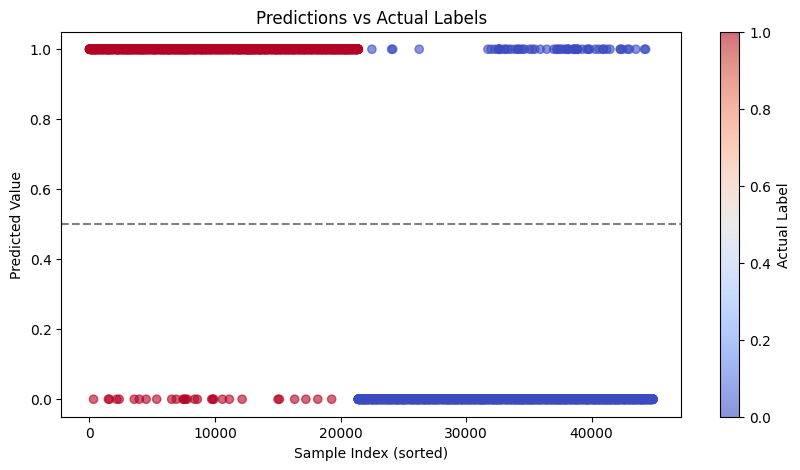

In [ ]:
plot_df_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plot_df_lr = plot_df_lr.sort_values('Predicted')

plt.figure(figsize=(10,5))

plt.scatter(plot_df_lr.index, plot_df_lr['Predicted'],
            c=plot_df_lr['Actual'], cmap='coolwarm', alpha=0.6)

plt.axhline(0.5, color='gray', linestyle='--')

plt.title('Predictions vs Actual Labels')

plt.xlabel('Sample Index (sorted)')
plt.ylabel('Predicted Value')

plt.colorbar(label='Actual Label')

plt.show()

In [ ]:
import hashlib

# Example news text (you can replace with dataset news)
news_text = "Example news article for blockchain verification"

# Generate SHA256 hash
news_hash = hashlib.sha256(news_text.encode()).hexdigest()

print("News Hash:")
print(news_hash)

News Hash:
155f2ab2fc2fd95098008ae4f13b0958e55abeac74ce9ce0189129b41bcae1ba


In [ ]:
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes

# Generate private and public keys
private_key = rsa.generate_private_key(
    public_exponent=65537,
    key_size=2048
)

public_key = private_key.public_key()

# Sign the hash
signature = private_key.sign(
    news_hash.encode(),
    padding.PSS(
        mgf=padding.MGF1(hashes.SHA256()),
        salt_length=padding.PSS.MAX_LENGTH
    ),
    hashes.SHA256()
)

print("Digital Signature Generated")
print(signature)

Digital Signature Generated
b'{\t\xc7"b\x94\xcc\xe1\xab\xb2\xa3o\x8d\xfc\xfd\x89\xda\xbf\x89\x9f\r\xfe\x9d6\x98G\xf8V\xfc\xed\x91\xa5\xb22\xe9o\xe6\xbb\x8e\x8c\x7f\x11k(\xe1\x83O\xe1\x95\xec&q3\xf1\xff,\x02q?\xde3c\xe6x\xe5\x9f\xc0b\xe6$\xf4\x06\xaf\x0bg\xaf4i\x0c\x9f7\x05\xc4\xfa\xd6u\xb0\xa6\x98?\xa5\xb15\xd3\xb4\xe4\xa6\xc4\x13\xa2j\xb9\xf33\xa7[#\xe4\xeaRd$=\x17T\xd7\xd7\xdb\x00\xfc\xe3\xfal\xb4\xef\xd6}N=\x9c+?\xa1\xf5\x98\ns\xc4\xd6D\xcb\xd2Q\xab\xb9%\xf3\xbb\x17^j*\x89*6\x9f\xb9\xcf\xeb\x8d\xfb(\x02\xae\x81\x1f\x8afK5q\xed\xbd\nL\xa8\x17@xH.\x926\x11\xea\xbf5\xd6}\x91,\xe8\xfd\xeffb\xd8\x19\xe1\x91\x07\x9a8\x8e\x88,\x0e\x1cz\xd1\x9dfF&\xdd\xa6\x90NX\x03\xfao\x88\xa2\xcf\x14\xd5\xe3\xe91\xedPRL\x14\xfeu\xb2%\xb7-\xda\x86\xa5\xb8T_W\xe7\xab\xc3\xd6\x98\x1b"\x8b'


In [ ]:
try:
    public_key.verify(
        signature,
        news_hash.encode(),
        padding.PSS(
            mgf=padding.MGF1(hashes.SHA256()),
            salt_length=padding.PSS.MAX_LENGTH
        ),
        hashes.SHA256()
    )

    print("✅ Signature Verified: News is authentic")

except:
    print("❌ Signature Verification Failed")

✅ Signature Verified: News is authentic


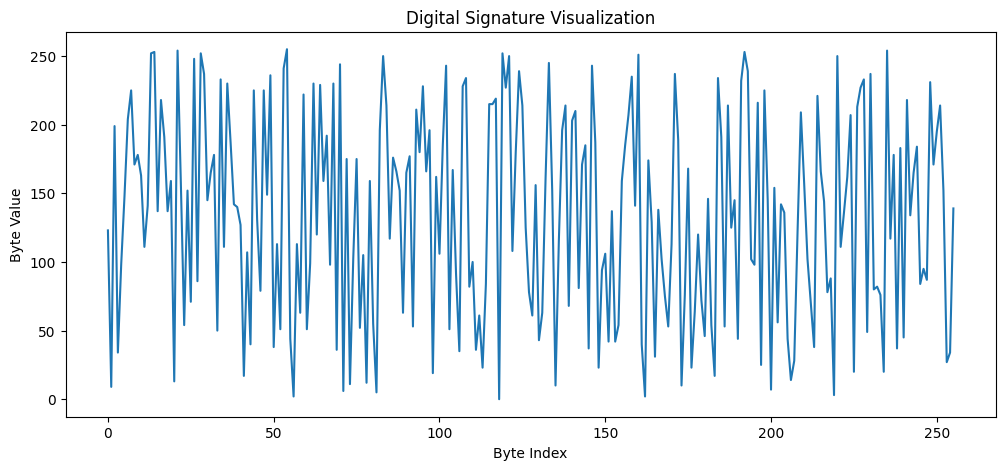

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert signature bytes to integers
sig_array = np.frombuffer(signature, dtype=np.uint8)

plt.figure(figsize=(12,5))

plt.plot(sig_array)

plt.title("Digital Signature Visualization")
plt.xlabel("Byte Index")
plt.ylabel("Byte Value")

plt.show()

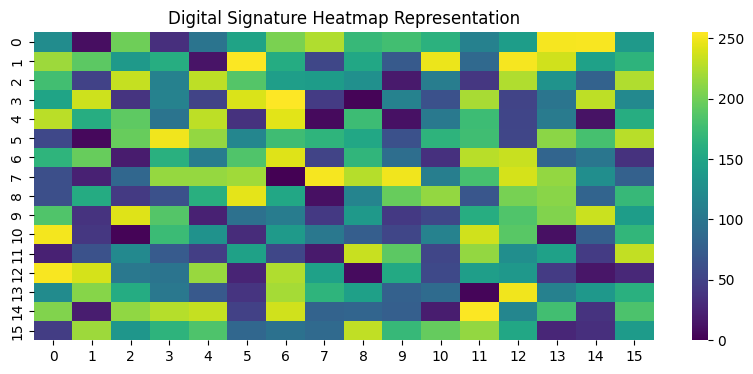

In [ ]:
import seaborn as sns

# reshape for heatmap
sig_matrix = sig_array.reshape(16, -1)

plt.figure(figsize=(10,4))

sns.heatmap(sig_matrix, cmap="viridis")

plt.title("Digital Signature Heatmap Representation")

plt.show()

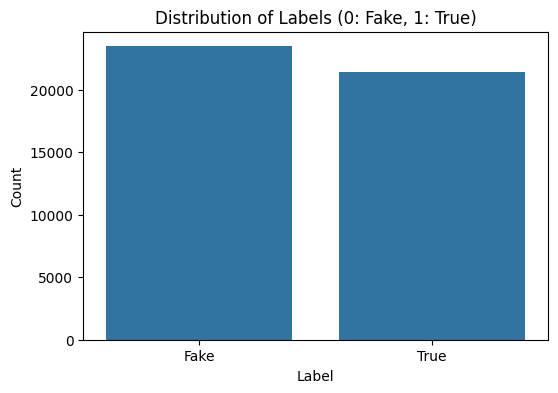

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Labels (0: Fake, 1: True)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake', 'True'])
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9898663697104677


In [ ]:
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

Model Accuracy: 98.99%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9898663697104677

Confusion Matrix:
[[4588   62]
 [  29 4301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4650
           1       0.99      0.99      0.99      4330

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
def predict_news(news_text):

    cleaned = news_text.lower()
    cleaned = re.sub(r'[^\w\s]', '', cleaned)

    tokens = cleaned.split()

    tokens = [word for word in tokens if word not in stop_words]

    vec = tfidf.transform([' '.join(tokens)])

    prediction = model.predict(vec)

    if prediction[0] == 1:
        return "Real"
    else:
        return "Fake"

In [ ]:
predict_news("Breaking news: government launches new policy today")

'Fake'

In [ ]:
predict_news("As U.S. budget fight looms, Republicans flip their fiscal script")

'Fake'

In [ ]:
predict_news("The United States Senate passed a new infrastructure bill on Tuesday after weeks of negotiations")

'Real'

In [ ]:
predict_news("Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal courts, the Pentagon said.")

'Real'